In [57]:
# import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [58]:
# Load csv

df = pd.read_csv("Fitbit_dataset.csv")
df

,Unnamed: 0,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Workout_Type,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI,Base_MET,HR_Intensity,Effective_MET,Calories_Burned (kcal)
0,0,56,Female,53.8,1.62,163.0,149.0,71.0,1.01,HIIT,22.1,3.5,3,1,20.4,9.5,0.847826,8.054348,437.7
1,1,46,Male,54.9,1.75,170.0,126.0,73.0,0.25,Yoga,19.9,3.4,3,0,18.0,3.0,0.546392,1.639175,22.5
2,2,32,Female,68.5,1.61,190.0,171.0,60.0,0.33,HIIT,20.4,2.7,3,1,26.5,9.5,0.853846,8.111538,183.4
3,3,25,Male,98.8,1.86,189.0,135.0,69.0,0.78,Yoga,30.3,4.4,3,0,28.5,3.0,0.550000,1.650000,127.2
4,4,38,Male,95.5,1.71,176.0,138.0,66.0,0.55,Cardio,23.7,2.2,2,0,32.5,7.0,0.654545,4.581818,240.7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14097,14097,18,Male,75.7,1.76,205.0,143.0,67.0,0.62,Yoga,23.3,3.7,4,1,24.3,3.0,0.550725,1.652174,77.5
14098,14098,54,Male,66.4,1.71,162.0,131.0,73.0,0.93,Cardio,15.0,2.7,3,1,22.7,7.0,0.651685,4.561798,281.7
14099,14099,23,Female,74.7,1.52,204.0,161.0,61.0,0.99,Strength,19.3,4.3,3,1,32.5,6.0,0.699301,4.195804,310.3
14100,14100,43,Male,70.8,1.69,171.0,154.0,55.0,1.01,HIIT,12.3,3.9,7,3,24.9,9.5,0.853448,8.107759,579.8


In [59]:
# SUPERVISED LEARNING #

In [60]:
# Remove unwanted column and check how the data is

print(df.head())

# Remove unnamed column

df = df.drop(columns=["Unnamed: 0"])

   Unnamed: 0  Age  Gender  ...  HR_Intensity  Effective_MET  Calories_Burned (kcal)
0           0   56  Female  ...      0.847826       8.054348                   437.7
1           1   46    Male  ...      0.546392       1.639175                    22.5
2           2   32  Female  ...      0.853846       8.111538                   183.4
3           3   25    Male  ...      0.550000       1.650000                   127.2
4           4   38    Male  ...      0.654545       4.581818                   240.7

[5 rows x 19 columns]


In [61]:
# checking data

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14102 entries, 0 to 14101
Data columns (total 18 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Age                            14102 non-null  int64  
 1   Gender                         14102 non-null  object 
 2   Weight (kg)                    14102 non-null  float64
 3   Height (m)                     14102 non-null  float64
 4   Max_BPM                        14102 non-null  float64
 5   Avg_BPM                        14102 non-null  float64
 6   Resting_BPM                    14102 non-null  float64
 7   Session_Duration (hours)       14102 non-null  float64
 8   Workout_Type                   14102 non-null  object 
 9   Fat_Percentage                 14102 non-null  float64
 10  Water_Intake (liters)          14102 non-null  float64
 11  Workout_Frequency (days/week)  14102 non-null  int64  
 12  Experience_Level               14102 non-null 

In [62]:
# converting object columns into int or float using label encode

from sklearn.preprocessing import LabelEncoder
label_enc = LabelEncoder()
df['Gender'] = label_enc.fit_transform(df['Gender'])
df['Workout_Type'] = label_enc.fit_transform(df['Workout_Type'])
df['Experience_Level'] = label_enc.fit_transform(df['Experience_Level'])

In [63]:
# Handling missing values

df = df.fillna(df.mean())
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14102 entries, 0 to 14101
Data columns (total 18 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Age                            14102 non-null  int64  
 1   Gender                         14102 non-null  int64  
 2   Weight (kg)                    14102 non-null  float64
 3   Height (m)                     14102 non-null  float64
 4   Max_BPM                        14102 non-null  float64
 5   Avg_BPM                        14102 non-null  float64
 6   Resting_BPM                    14102 non-null  float64
 7   Session_Duration (hours)       14102 non-null  float64
 8   Workout_Type                   14102 non-null  int64  
 9   Fat_Percentage                 14102 non-null  float64
 10  Water_Intake (liters)          14102 non-null  float64
 11  Workout_Frequency (days/week)  14102 non-null  int64  
 12  Experience_Level               14102 non-null 

In [64]:
# check skewness for the numerical values 

import pandas as pd

# Select only numeric columns
numeric_cols = df.select_dtypes(include=['int64', 'float64'])

# Calculate skewness
skew_values = numeric_cols.skew()

print(skew_values)


Age                              0.003135
Gender                          -0.020142
Weight (kg)                      0.416550
Height (m)                      -0.012917
Max_BPM                         -0.047057
Avg_BPM                          0.185845
Resting_BPM                     -0.069268
Session_Duration (hours)         0.191875
Workout_Type                     0.007940
Fat_Percentage                  -0.094860
Water_Intake (liters)            0.020722
Workout_Frequency (days/week)    0.392939
Experience_Level                 0.443009
BMI                              0.275033
Base_MET                        -0.525490
HR_Intensity                    -0.016123
Effective_MET                   -0.032219
Calories_Burned (kcal)           1.042262
dtype: float64


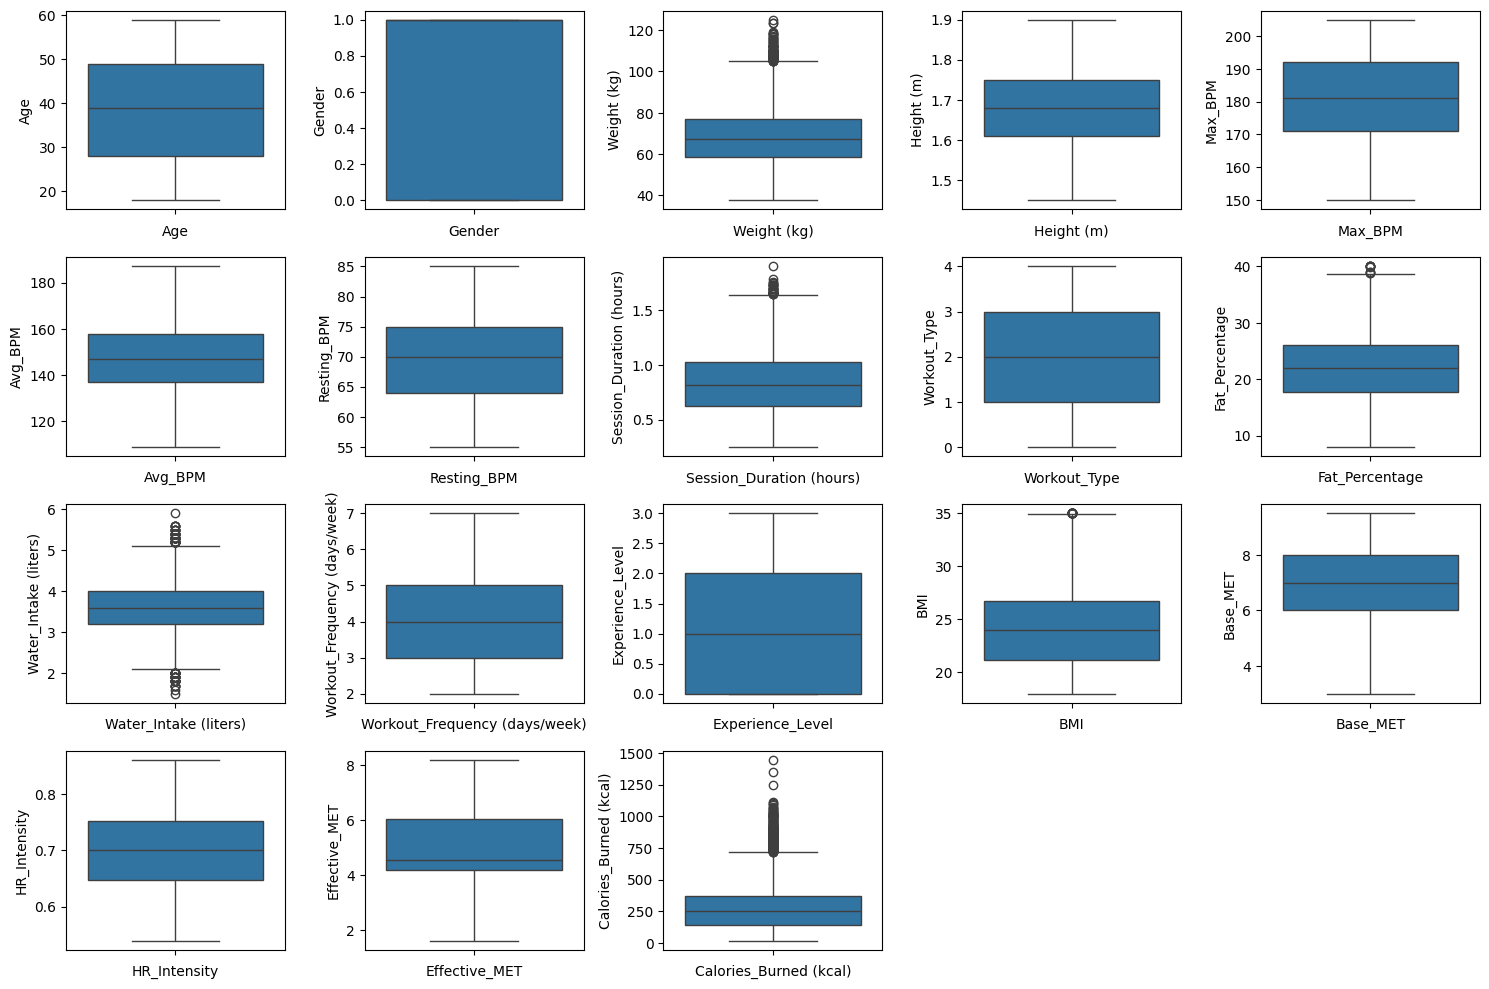

In [65]:
# showing data in box plot before capping

import matplotlib.pyplot as plt
import seaborn as sns

numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

plt.figure(figsize=(15, 10))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(4, 5, i)
    sns.boxplot(y=df[col])
    # no title here
    plt.xlabel(col)   # optional: show column name on x-axis instead

plt.tight_layout()
plt.show()


In [66]:
# outliers handling using IQR method and capping

import pandas as pd

# Assuming your dataset is loaded into df
# Example: df = pd.read_csv("fitness_data.csv")

numeric_cols = [
    "Age", "Weight (kg)", "Height (m)", "Max_BPM", "Avg_BPM", "Resting_BPM",
    "Session_Duration (hours)", "Fat_Percentage", "Water_Intake (liters)",
    "Workout_Frequency (days/week)", "BMI", "Base_MET", "HR_Intensity",
    "Effective_MET", "Calories_Burned (kcal)"
]

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Cap values outside bounds
    df[col] = df[col].clip(lower=lower_bound, upper=upper_bound)

print("Extreme values capped using IQR method.")


Extreme values capped using IQR method.


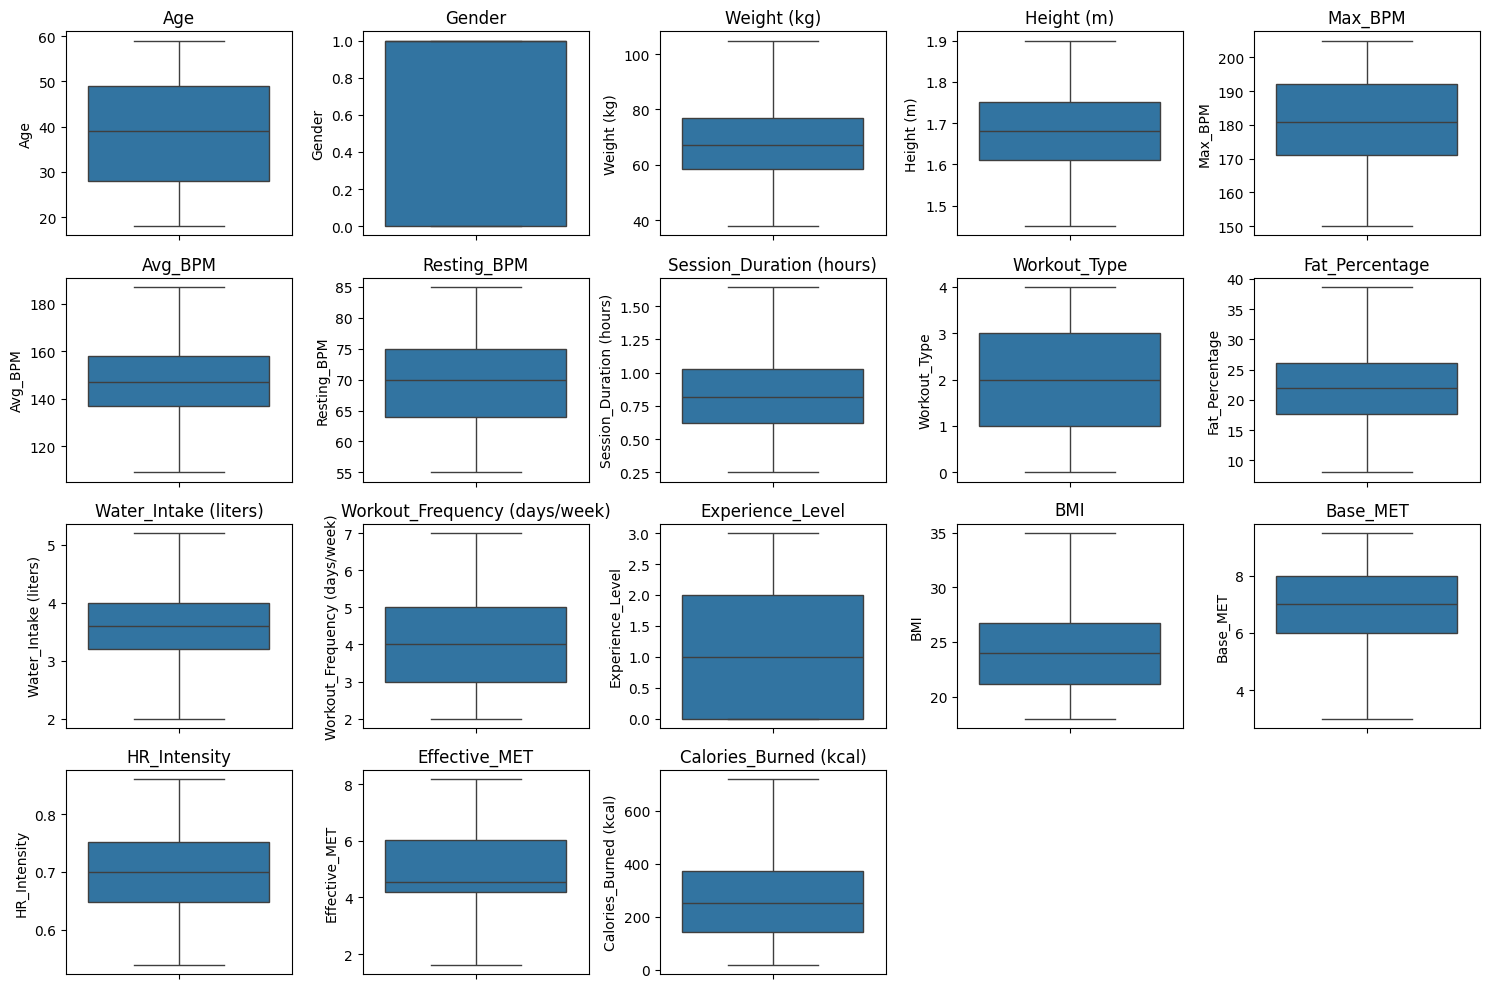

In [67]:
# box plot after capping

import matplotlib.pyplot as plt
import seaborn as sns

numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

plt.figure(figsize=(15, 10))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(4, 5, i)
    sns.boxplot(y=df[col])
    plt.title(col)   # clearer than xlabel for boxplots

plt.tight_layout()
plt.show()


In [68]:
# Feature scaling & preprocessing

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X = df.drop("Calories_Burned (kcal)", axis=1)
y = df["Calories_Burned (kcal)"]
X_scaled = scaler.fit_transform(X)

In [69]:
# Split test and train

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)


In [70]:
# Applying regression models

from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Dictionary of models
models = {
    "Linear Regression": LinearRegression(),
    "KNN Regressor": KNeighborsRegressor(n_neighbors=5),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42),
    "Support Vector Regression": SVR(),
    "XGBoost": XGBRegressor(random_state=42)
}

# Train and evaluate each model
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    
    print(f"{name} -> MAE: {mae:.2f}, RMSE: {rmse:.2f}, R2: {r2:.2f}")


Linear Regression -> MAE: 31.77, RMSE: 45.73, R2: 0.93
KNN Regressor -> MAE: 28.21, RMSE: 39.20, R2: 0.95
Decision Tree -> MAE: 7.43, RMSE: 11.65, R2: 1.00
Random Forest -> MAE: 3.66, RMSE: 7.08, R2: 1.00
Support Vector Regression -> MAE: 28.22, RMSE: 49.20, R2: 0.91
XGBoost -> MAE: 5.17, RMSE: 7.87, R2: 1.00


✅ KNN Regressor saved as knn_model.pkl
Sample predictions from loaded KNN: [396.3  462.4   98.54 158.36 183.9 ]


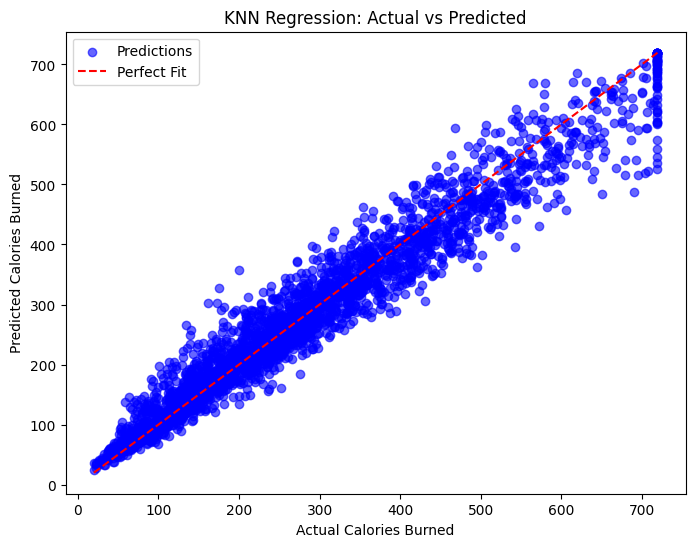

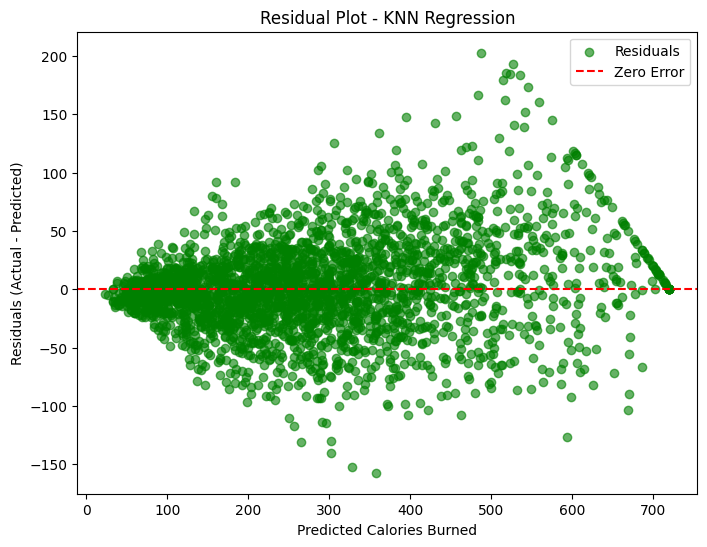

In [71]:
# KNN Regressor visualization

# KNN Regressor Save, Load, Test, and Visualization

import pickle
import matplotlib.pyplot as plt

# --- 1. Save the trained KNN model ---
knn = models["KNN Regressor"]   # Assuming 'models' dict already has your trained KNN
with open("knn_model.pkl", "wb") as f:
    pickle.dump(knn, f)

print("✅ KNN Regressor saved as knn_model.pkl")

# --- 2. Load the model back ---
with open("E:/vscode/Fitbit_Project/knn_model.pkl", "rb") as f:
    loaded_knn = pickle.load(f)

# --- 3. Test loaded model ---
y_pred = loaded_knn.predict(X_test)
print("Sample predictions from loaded KNN:", y_pred[:5])

# --- 4. Visualization using the loaded model ---

# Actual vs Predicted Plot
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.6, color="blue", label="Predictions")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label="Perfect Fit")
plt.xlabel("Actual Calories Burned")
plt.ylabel("Predicted Calories Burned")
plt.title("KNN Regression: Actual vs Predicted")
plt.legend()
plt.show()

# Residual Plot
residuals = y_test - y_pred
plt.figure(figsize=(8,6))
plt.scatter(y_pred, residuals, alpha=0.6, color="green", label="Residuals")
plt.axhline(y=0, color='red', linestyle='--', label="Zero Error")
plt.xlabel("Predicted Calories Burned")
plt.ylabel("Residuals (Actual - Predicted)")
plt.title("Residual Plot - KNN Regression")
plt.legend()
plt.show()


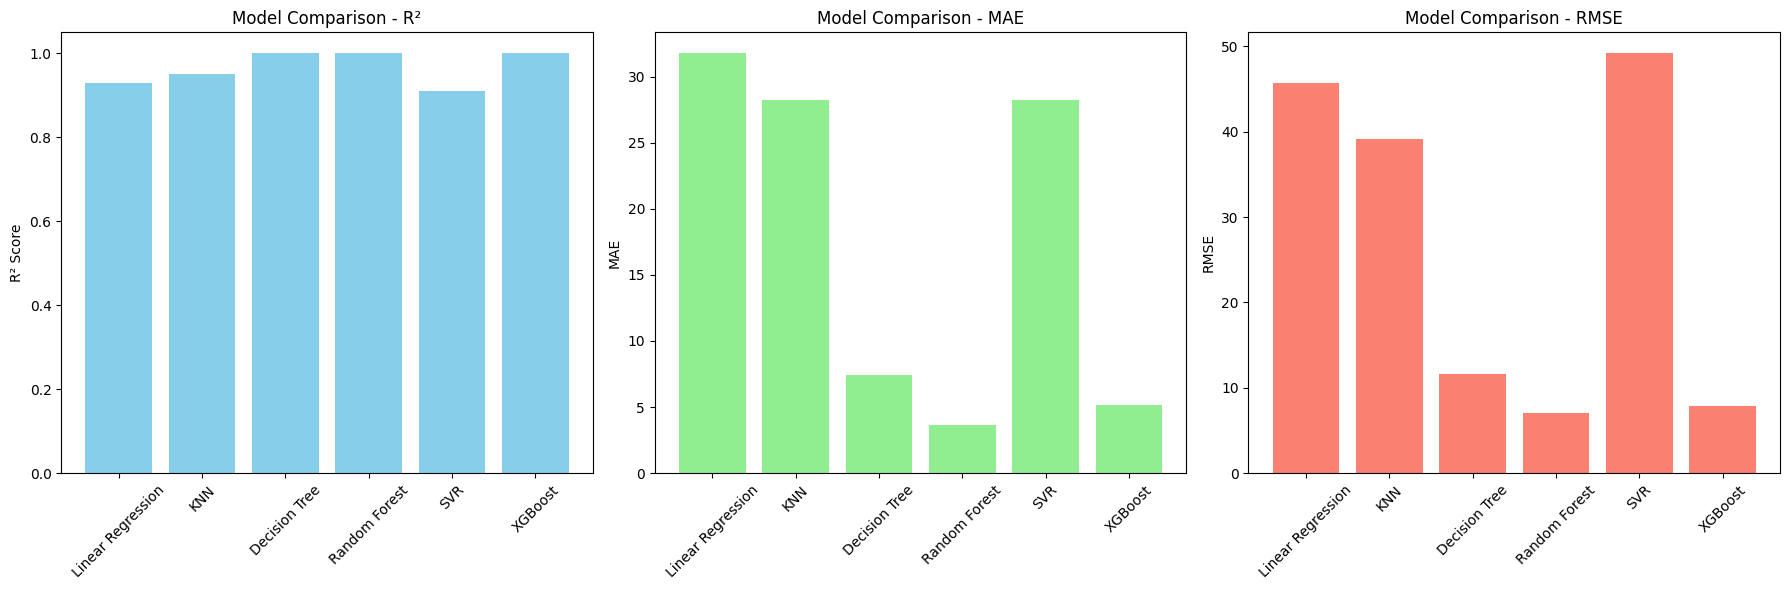

In [72]:
# Model comparision bar chart

import matplotlib.pyplot as plt
import pandas as pd

# Model evaluation results
results = {
    "Model": ["Linear Regression", "KNN", "Decision Tree", "Random Forest", "SVR", "XGBoost"],
    "MAE": [31.77, 28.21, 7.43, 3.66, 28.22, 5.17],
    "RMSE": [45.73, 39.20, 11.65, 7.08, 49.20, 7.87],
    "R2": [0.93, 0.95, 1.00, 1.00, 0.91, 1.00]
}

df_results = pd.DataFrame(results)

# Create subplots for all three metrics
fig, axes = plt.subplots(1, 3, figsize=(18,6))

# R² comparison
axes[0].bar(df_results["Model"], df_results["R2"], color="skyblue")
axes[0].set_ylabel("R² Score")
axes[0].set_title("Model Comparison - R²")
axes[0].tick_params(axis='x', rotation=45)

# MAE comparison
axes[1].bar(df_results["Model"], df_results["MAE"], color="lightgreen")
axes[1].set_ylabel("MAE")
axes[1].set_title("Model Comparison - MAE")
axes[1].tick_params(axis='x', rotation=45)

# RMSE comparison
axes[2].bar(df_results["Model"], df_results["RMSE"], color="salmon")
axes[2].set_ylabel("RMSE")
axes[2].set_title("Model Comparison - RMSE")
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()



In [73]:
# UNSUPERVISED LEARNING

In [74]:
# importing required libraries

import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns


In [75]:
# Remove unwanted column and check how the data is

print(df.head())

   Age  Gender  ...  Effective_MET  Calories_Burned (kcal)
0   56       0  ...       8.054348                   437.7
1   46       1  ...       1.639175                    22.5
2   32       0  ...       8.111538                   183.4
3   25       1  ...       1.650000                   127.2
4   38       1  ...       4.581818                   240.7

[5 rows x 18 columns]


In [76]:
# Drop targets

df_clustering = df.drop(columns=["Workout_Type", "Calories_Burned (kcal)"])


In [77]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14102 entries, 0 to 14101
Data columns (total 18 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Age                            14102 non-null  int64  
 1   Gender                         14102 non-null  int64  
 2   Weight (kg)                    14102 non-null  float64
 3   Height (m)                     14102 non-null  float64
 4   Max_BPM                        14102 non-null  float64
 5   Avg_BPM                        14102 non-null  float64
 6   Resting_BPM                    14102 non-null  float64
 7   Session_Duration (hours)       14102 non-null  float64
 8   Workout_Type                   14102 non-null  int64  
 9   Fat_Percentage                 14102 non-null  float64
 10  Water_Intake (liters)          14102 non-null  float64
 11  Workout_Frequency (days/week)  14102 non-null  int64  
 12  Experience_Level               14102 non-null 

In [78]:
# Encoding 

from sklearn.preprocessing import StandardScaler

# Drop target variable (Workout_Type) and any other non-numeric columns
features = df.drop(["Workout_Type", "Cluster"], axis=1, errors="ignore")

# Keep only numeric columns
numeric_features = features.select_dtypes(include=['int64','float64'])

# Scale numeric data
scaler = StandardScaler()
scaled_data = scaler.fit_transform(numeric_features)

# Create scaled DataFrame
scaled_df = pd.DataFrame(scaled_data, columns=numeric_features.columns)


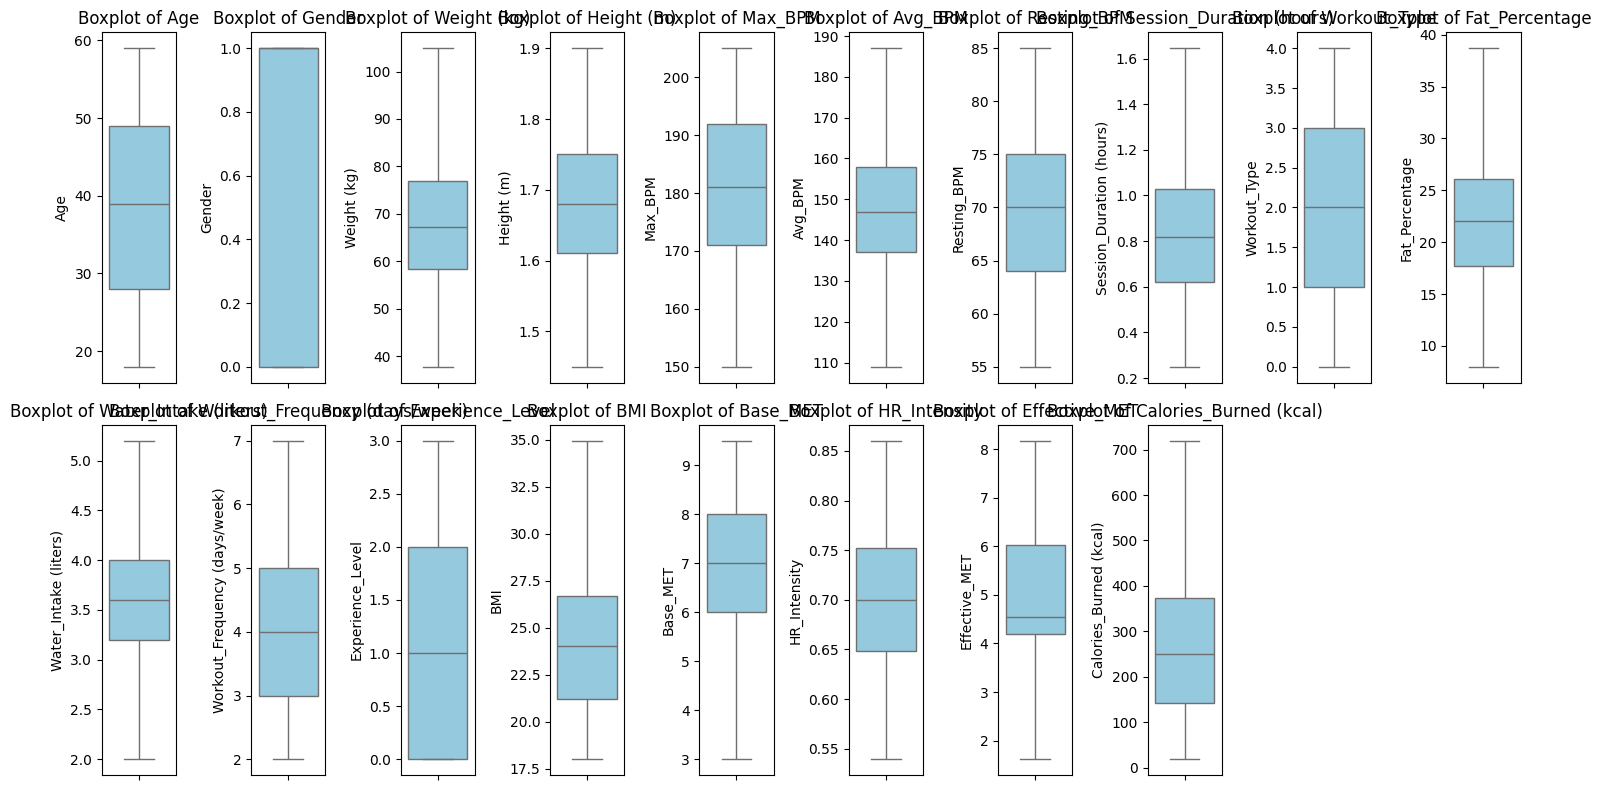

In [79]:
# Plots 

import matplotlib.pyplot as plt
import seaborn as sns

numeric_cols = df.select_dtypes(include=['int64','float64']).columns

plt.figure(figsize=(15,8))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(2, (len(numeric_cols)//2)+1, i)
    sns.boxplot(y=df[col], color="skyblue")
    plt.title(f"Boxplot of {col}")
plt.tight_layout()
plt.show()


In [80]:
# scale features
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Step 1: Select features (drop target and cluster if present)
features = df.drop(["Workout_Type", "Cluster"], axis=1, errors="ignore")

# Step 2: Keep only numeric columns
numeric_features = features.select_dtypes(include=['int64','float64'])

# Step 3: Scale numeric data
scaler = StandardScaler()
scaled_data = scaler.fit_transform(numeric_features)

# Step 4: Create scaled DataFrame
scaled_df = pd.DataFrame(scaled_data, columns=numeric_features.columns)

print("Scaled data shape:", scaled_df.shape)
print(scaled_df.head())


Scaled data shape: (14102, 17)
        Age    Gender  ...  Effective_MET  Calories_Burned (kcal)
0  1.455052 -1.010121  ...       1.473327                0.970387
1  0.622244  0.989981  ...      -1.546762               -1.539917
2 -0.543688 -1.010121  ...       1.500251               -0.567114
3 -1.126653  0.989981  ...      -1.541666               -0.906900
4 -0.044003  0.989981  ...      -0.161446               -0.220677

[5 rows x 17 columns]


In [81]:
# PCA

from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_data = pca.fit_transform(scaled_data)
print("Explained variance ratio:", pca.explained_variance_ratio_)


Explained variance ratio: [0.25734778 0.23141152]


In [82]:
# Kmeans + silhoutte score

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Try different cluster numbers
silhouette_scores = {}
for k in range(2, 8):   # you can expand this range if needed
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(pca_data)
    score = silhouette_score(pca_data, labels)
    silhouette_scores[k] = score
    print(f"Clusters: {k}, Silhouette Score: {score:.3f}")

# Pick the best k
best_k = max(silhouette_scores, key=silhouette_scores.get)
best_score = silhouette_scores[best_k]

print("\nBest number of clusters:", best_k)
print("Best silhouette score:", round(best_score, 3))

# Fit final KMeans model with best_k
kmeans = KMeans(n_clusters=best_k, random_state=42)
labels = kmeans.fit_predict(pca_data)
df["Cluster"] = labels



Clusters: 2, Silhouette Score: 0.329
Clusters: 3, Silhouette Score: 0.389
Clusters: 4, Silhouette Score: 0.386
Clusters: 5, Silhouette Score: 0.380
Clusters: 6, Silhouette Score: 0.407
Clusters: 7, Silhouette Score: 0.403

Best number of clusters: 6
Best silhouette score: 0.407


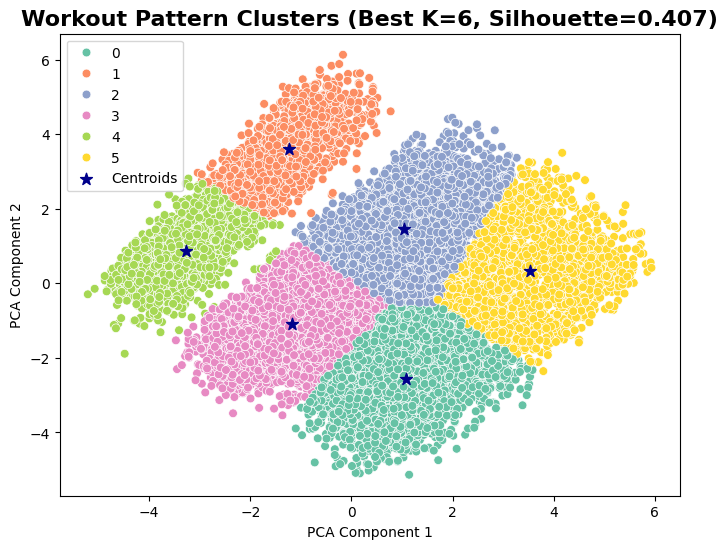

In [83]:
import matplotlib.pyplot as plt
import seaborn as sns

# Make sure you have this line after fitting KMeans:
# df["Cluster"] = labels

plt.figure(figsize=(8,6))

# Scatter plot of PCA data colored by KMeans cluster labels
sns.scatterplot(
    x=pca_data[:,0], 
    y=pca_data[:,1], 
    hue=df["Cluster"],   # use the column you actually created
    palette="Set2", 
    s=40
)

# Plot cluster centroids
plt.scatter(
    kmeans.cluster_centers_[:,0], 
    kmeans.cluster_centers_[:,1], 
    c="darkblue", 
    s=80, 
    marker="*", 
    label="Centroids"
)

# Add title with silhouette score
plt.title(
    f"Workout Pattern Clusters (Best K={best_k}, Silhouette={best_score:.3f})", 
    fontsize=16, fontweight="bold"
)
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.legend()
plt.show()


In [84]:
import pickle

# Save the trained KMeans model
with open("kmeans_best.pkl", "wb") as f:
    pickle.dump(kmeans, f)

print("Model saved as kmeans_best.pkl")


Model saved as kmeans_best.pkl


In [85]:
# Load the model back
with open("kmeans_best.pkl", "rb") as f:
    loaded_model = pickle.load(f)

# Predict again using the loaded model
new_labels = loaded_model.predict(pca_data)


In [86]:
# Add DBSCAN here after PCA
dbscan = DBSCAN(eps=0.5, min_samples=5)  # tune eps & min_samples
dbscan_labels = dbscan.fit_predict(pca_data)

df["Cluster_DBSCAN"] = dbscan_labels

# Evaluate DBSCAN (only if more than 1 cluster is found)
if len(set(dbscan_labels)) > 1 and -1 not in set(dbscan_labels):
    dbscan_score = silhouette_score(pca_data, dbscan_labels)
    print("DBSCAN silhouette score:", round(dbscan_score, 3))
else:
    print("DBSCAN produced noise or single cluster, silhouette score not applicable.")

DBSCAN produced noise or single cluster, silhouette score not applicable.


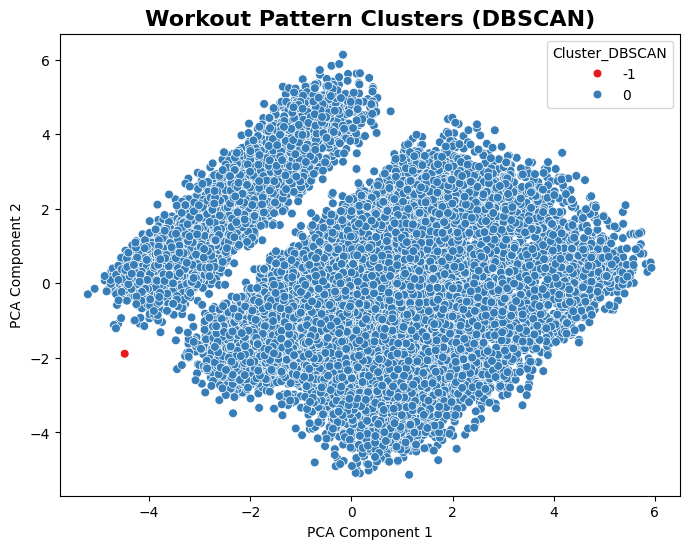

In [87]:
# Visualization

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))

# Scatter plot of PCA data colored by DBSCAN cluster labels
sns.scatterplot(
    x=pca_data[:,0], 
    y=pca_data[:,1], 
    hue=df["Cluster_DBSCAN"], 
    palette="Set1", 
    s=40
)

plt.title("Workout Pattern Clusters (DBSCAN)", fontsize=16, fontweight="bold")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.show()


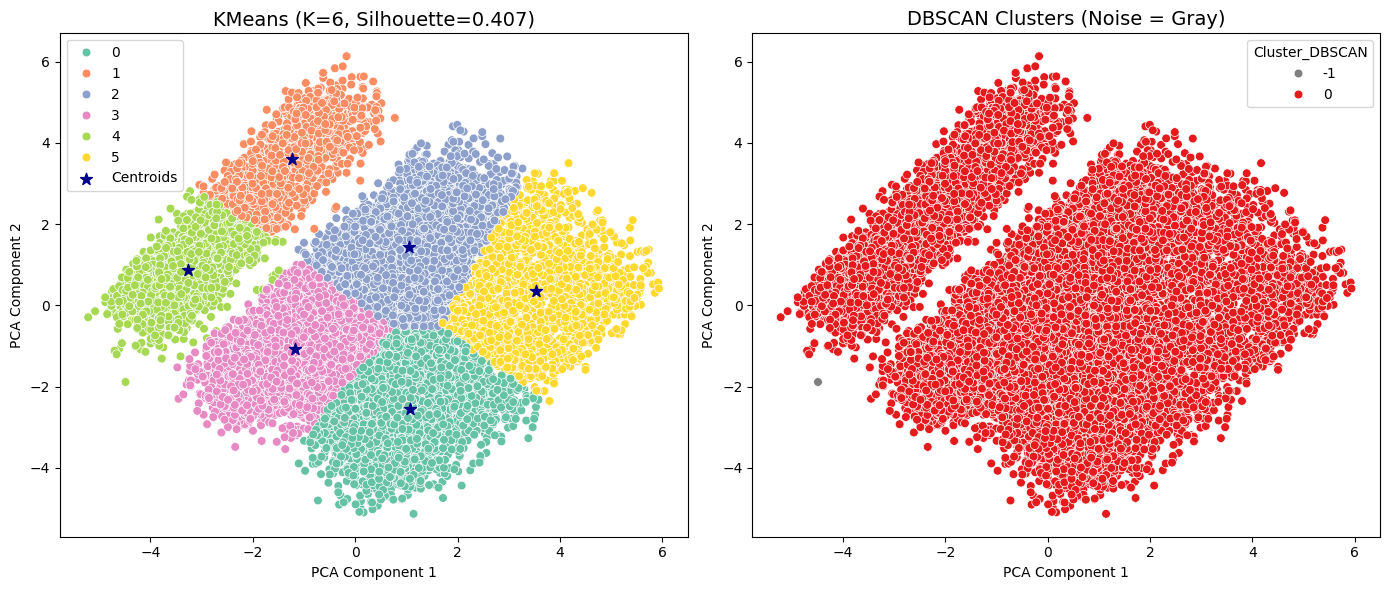

In [88]:
# kmeans vs dbscan comparision

import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14,6))

# KMeans plot
sns.scatterplot(
    x=pca_data[:,0], y=pca_data[:,1],
    hue=df["Cluster"], palette="Set2", s=40, ax=axes[0]
)
axes[0].scatter(
    kmeans.cluster_centers_[:,0], kmeans.cluster_centers_[:,1],
    c="darkblue", s=80, marker="*", label="Centroids"
)
axes[0].set_title(f"KMeans (K={best_k}, Silhouette={best_score:.3f})", fontsize=14)
axes[0].set_xlabel("PCA Component 1")
axes[0].set_ylabel("PCA Component 2")
axes[0].legend()

# DBSCAN plot
palette = sns.color_palette("Set1", len(set(df["Cluster_DBSCAN"])) - (1 if -1 in df["Cluster_DBSCAN"].values else 0))
palette = dict(zip([c for c in set(df["Cluster_DBSCAN"]) if c != -1], palette))
palette[-1] = "gray"  # noise points

sns.scatterplot(
    x=pca_data[:,0], y=pca_data[:,1],
    hue=df["Cluster_DBSCAN"], palette=palette, s=40, ax=axes[1]
)
axes[1].set_title("DBSCAN Clusters (Noise = Gray)", fontsize=14)
axes[1].set_xlabel("PCA Component 1")
axes[1].set_ylabel("PCA Component 2")

plt.tight_layout()
plt.show()


In [89]:
# Cluster analysis

print(df.dtypes)


Age                                int64
Gender                             int64
Weight (kg)                      float64
Height (m)                       float64
Max_BPM                          float64
Avg_BPM                          float64
Resting_BPM                      float64
Session_Duration (hours)         float64
Workout_Type                       int64
Fat_Percentage                   float64
Water_Intake (liters)            float64
Workout_Frequency (days/week)      int64
Experience_Level                   int64
BMI                              float64
Base_MET                         float64
HR_Intensity                     float64
Effective_MET                    float64
Calories_Burned (kcal)           float64
Cluster                            int32
Cluster_DBSCAN                     int64
dtype: object


In [90]:
numeric_cols = df.select_dtypes(include=['int64','float64']).columns
cluster_means = df.groupby("Cluster")[numeric_cols].mean()
print(cluster_means)


               Age    Gender  ...  Calories_Burned (kcal)  Cluster_DBSCAN
Cluster                       ...                                        
0        35.829362  0.489362  ...              356.613277        0.000000
1        39.339506  0.544092  ...              120.176631        0.000000
2        40.781361  0.522090  ...              332.442599        0.000000
3        39.217547  0.493904  ...              202.399331        0.000000
4        38.040557  0.470339  ...               74.492736       -0.000605
5        36.363853  0.530916  ...              555.377229        0.000000

[6 rows x 19 columns]


In [91]:
# compare cluster across experience level 

experience_mapping = {
    0: "Beginner",
    1: "Intermediate",
    2: "Advanced",
    3: "Expert"
}

df["Experience_Level"] = df["Experience_Level"].map(experience_mapping)


experience_cluster = df.groupby(["Cluster","Experience_Level"]).size().unstack(fill_value=0)
print(experience_cluster)


Experience_Level  Advanced  Beginner  Expert  Intermediate
Cluster                                                   
0                       60      1299       0           991
1                      541         0     403           190
2                     1458         1     919           723
3                       43      2621       0          1519
4                        9       994       0           649
5                      777         0     753           152


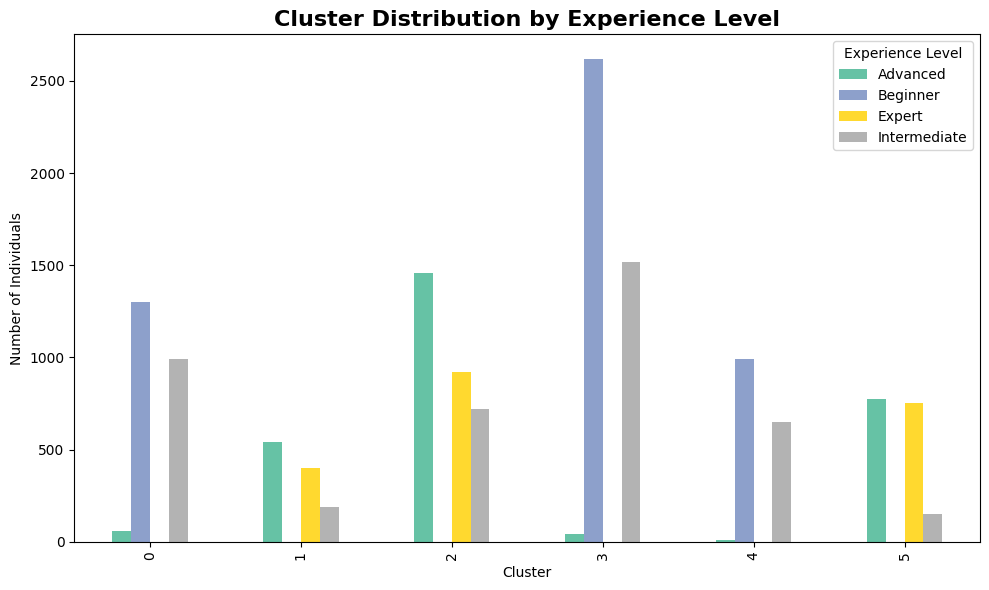

In [92]:
# chart for visualization

import matplotlib.pyplot as plt

# Use the table you already created (experience_cluster)
experience_cluster.plot(kind="bar", figsize=(10,6), colormap="Set2")

plt.title("Cluster Distribution by Experience Level", fontsize=16, fontweight="bold")
plt.xlabel("Cluster")
plt.ylabel("Number of Individuals")
plt.legend(title="Experience Level")
plt.tight_layout()
plt.show()
